In [1]:
import sys
import os
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import pandas as pd
import shutil
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.torch_lightning.lightning_data_module import DroneDataModule
from src.torch_lightning.lightning_module import DroneClassifier

pl.seed_everything(42)

Seed set to 42


42

In [2]:
ROOT_DIR = "data"
BATCH_SIZE = 16
NUM_WORKERS = 0

SAMPLE_RATE = 16000
DURATION = 2.0
N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256

LEARNING_RATE = 1e-3
MAX_EPOCHS = 20

VARIANTS = ["original", "noisy", "noisy_kalman"]

RESULTS = []

In [3]:
if os.path.exists("logs"):
    shutil.rmtree("logs")
    print("Usunięto folder logs")

if os.path.exists("results"):
    shutil.rmtree("results")
    print("Usunięto folder results")

RESULTS = []
print("Zresetowano RESULTS")

Usunięto folder logs
Zresetowano RESULTS


In [4]:
def run_experiment(dataset_type: str, variant: str):
    print("\n" + "=" * 80)
    print(f"START: dataset_type={dataset_type} | variant={variant}")
    print("=" * 80)

    dm = DroneDataModule(
        root_dir=ROOT_DIR,
        dataset_type=dataset_type,
        variant=variant,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        sample_rate=SAMPLE_RATE,
        duration=DURATION,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        noise_std=0.0003,
        kalman_q=1e-1,
        kalman_r=1e-1,
        seed=42,
    )

    dm.prepare_data()
    dm.setup()

    num_classes = len(dm.class_to_idx)

    model = DroneClassifier(
        num_classes=num_classes,
        n_mels=N_MELS,
        learning_rate=LEARNING_RATE,
    )

    experiment_name = f"{dataset_type}_{variant}"

    logger = CSVLogger(
        save_dir="logs",
        name="drone_mamba",
        version=experiment_name,
    )

    checkpoint_callback = ModelCheckpoint(
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        filename=experiment_name + "-{epoch:02d}-{val_acc:.4f}",
    )

    early_stopping = EarlyStopping(
        monitor="val_acc",
        mode="max",
        patience=5,
    )

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="auto",
        devices=1,
        logger=logger,
        callbacks=[checkpoint_callback, early_stopping],
        log_every_n_steps=10,
    )

    trainer.fit(model, datamodule=dm)
    test_results = trainer.test(model, datamodule=dm)

    result_row = {
        "dataset_type": dataset_type,
        "variant": variant,
        "num_classes": num_classes,
        "best_checkpoint": checkpoint_callback.best_model_path,
    }

    if len(test_results) > 0:
        for key, value in test_results[0].items():
            result_row[key] = value

    RESULTS.append(result_row)

    print(f"BEST CHECKPOINT: {checkpoint_callback.best_model_path}")
    print("=" * 80)

    return result_row

In [5]:
dm_original = DroneDataModule(root_dir=ROOT_DIR, dataset_type="binary", variant="original", batch_size=1)
dm_noisy = DroneDataModule(root_dir=ROOT_DIR, dataset_type="binary", variant="noisy", batch_size=1)
dm_kalman = DroneDataModule(root_dir=ROOT_DIR, dataset_type="binary", variant="noisy_kalman", batch_size=1)

dm_original.prepare_data(); dm_original.setup()
dm_noisy.prepare_data(); dm_noisy.setup()
dm_kalman.prepare_data(); dm_kalman.setup()

x_orig, y_orig = dm_original.train_dataset[1]
x_noisy, y_noisy = dm_noisy.train_dataset[1]
x_kalman, y_kalman = dm_kalman.train_dataset[1]

print("Label original:", y_orig.item())
print("Label noisy:", y_noisy.item())
print("Label kalman:", y_kalman.item())

print("Original mean/std:", x_orig.mean().item(), x_orig.std().item())
print("Noisy mean/std:", x_noisy.mean().item(), x_noisy.std().item())
print("Kalman mean/std:", x_kalman.mean().item(), x_kalman.std().item())

print("orig vs noisy equal:", bool((x_orig == x_noisy).all()))
print("orig vs kalman equal:", bool((x_orig == x_kalman).all()))
print("noisy vs kalman equal:", bool((x_noisy == x_kalman).all()))

Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: original
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy_kalman
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Label original: 0
Label noisy: 0
Label kalman: 0
Original mean/std: 0.1268196403980255 0.17492102086544037
Noisy mean/std: 0.23306338489055634 0.1205848976969719
Kalman mean/std: 0.22120994329452515 0.15550439059734344
orig vs noisy equal: False
orig vs kalman equal: False
noisy vs kalman equal: False


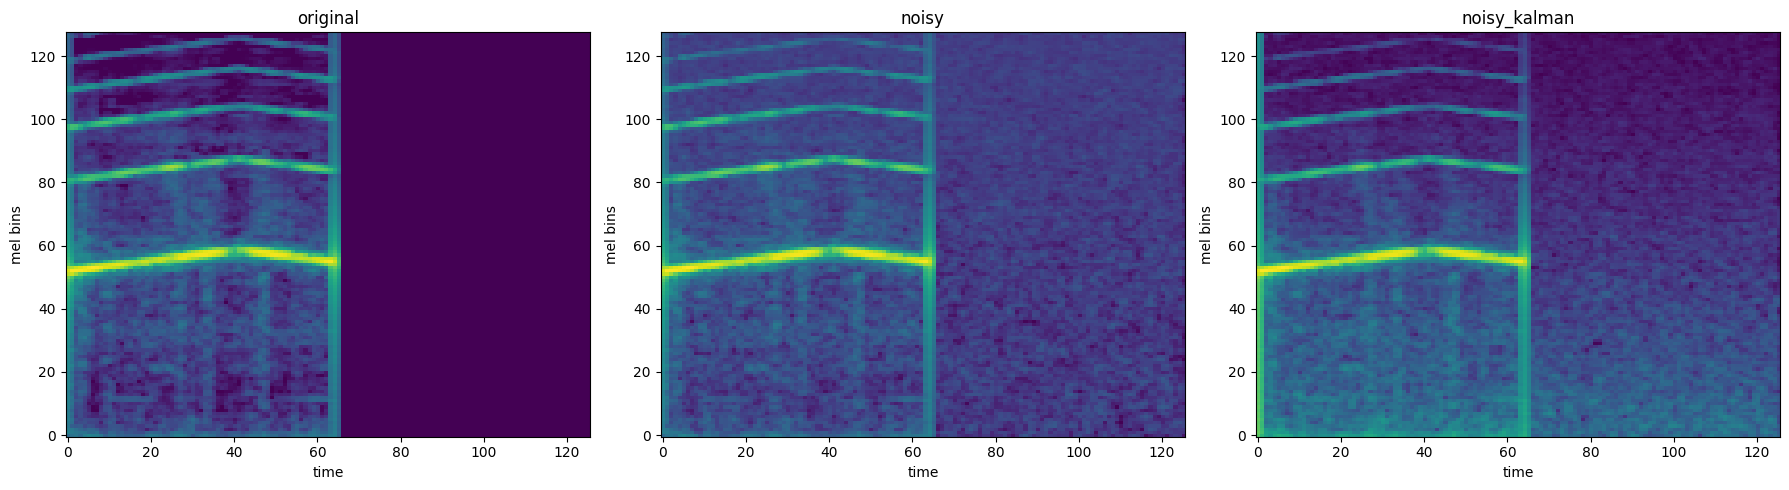

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(x_orig.squeeze(0).numpy(), aspect="auto", origin="lower")
axes[0].set_title("original")

axes[1].imshow(x_noisy.squeeze(0).numpy(), aspect="auto", origin="lower")
axes[1].set_title("noisy")

axes[2].imshow(x_kalman.squeeze(0).numpy(), aspect="auto", origin="lower")
axes[2].set_title("noisy_kalman")

for ax in axes:
    ax.set_xlabel("time")
    ax.set_ylabel("mel bins")

plt.tight_layout()
plt.show()

In [7]:
RESULTS = []
run_experiment(dataset_type="binary", variant="original")


START: dataset_type=binary | variant=original
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: original
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: original
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757



  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Epoch 5: 100%|██████████| 512/512 [01:15<00:00,  6.82it/s, v_num=inal, val_loss=0.156, val_acc=0.875, train_loss=0.191, train_acc=0.888]
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: original
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 110/110 [00:33<00:00,  3.31it/s]
Confusion Matrix:
tensor([[1564,    0],
        [ 193,    0]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:33<00:00,  3.30it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8901536464691162
         test_f1            0.47094249725341797
        test_loss           0.13952508568763733
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST CHECKPOINT: logs\drone_mamba\binary_original\checkpoints\binary_original-epoch=00-val_acc=0.8752.ckpt


{'dataset_type': 'binary',
 'variant': 'original',
 'num_classes': 2,
 'best_checkpoint': 'logs\\drone_mamba\\binary_original\\checkpoints\\binary_original-epoch=00-val_acc=0.8752.ckpt',
 'test_loss': 0.13952508568763733,
 'test_acc': 0.8901536464691162,
 'test_f1': 0.47094249725341797}

In [8]:
run_experiment(dataset_type="binary", variant="noisy")


START: dataset_type=binary | variant=noisy
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Epoch 13: 100%|██████████| 512/512 [01:24<00:00,  6.04it/s, v_num=oisy, val_loss=0.0433, val_acc=0.985, train_loss=0.0489, train_acc=0.984]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Testing DataLoader 0: 100%|██████████| 110/110 [00:18<00:00,  6.06it/s]
Confusion Matrix:
tensor([[1546,   18],
        [   4,  189]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:18<00:00,  6.05it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9874786734580994
         test_f1            0.9689675569534302
        test_loss           0.03306619077920914
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST CHECKP

{'dataset_type': 'binary',
 'variant': 'noisy',
 'num_classes': 2,
 'best_checkpoint': 'logs\\drone_mamba\\binary_noisy\\checkpoints\\binary_noisy-epoch=08-val_acc=0.9966.ckpt',
 'test_loss': 0.03306619077920914,
 'test_acc': 0.9874786734580994,
 'test_f1': 0.9689675569534302}

In [9]:
run_experiment(dataset_type="binary", variant="noisy_kalman")


START: dataset_type=binary | variant=noisy_kalman
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy_kalman
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy_kalman
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757
Epoch 5: 100%|██████████| 512/512 [03:50<00:00,  2.22it/s, v_num=lman, val_loss=0.148, val_acc=0.875, train_loss=0.190, train_acc=0.887]
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Binary_Drone_Audio
Dataset type: binary
Variant: noisy_kalman
Class to idx: {'unknown': 0, 'yes_drone': 1}
Train size: 8192
Val size: 1755
Test size: 1757


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 110/110 [00:43<00:00,  2.52it/s]
Confusion Matrix:
tensor([[1564,    0],
        [ 193,    0]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:43<00:00,  2.52it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8901536464691162
         test_f1            0.47094249725341797
        test_loss           0.1418008804321289
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST CHECKPOINT: logs\drone_mamba\binary_noisy_kalman\checkpoints\binary_noisy_kalman-epoch=00-val_acc=0.8752.ckpt


{'dataset_type': 'binary',
 'variant': 'noisy_kalman',
 'num_classes': 2,
 'best_checkpoint': 'logs\\drone_mamba\\binary_noisy_kalman\\checkpoints\\binary_noisy_kalman-epoch=00-val_acc=0.8752.ckpt',
 'test_loss': 0.1418008804321289,
 'test_acc': 0.8901536464691162,
 'test_f1': 0.47094249725341797}

In [10]:
results_df = pd.DataFrame(RESULTS)
results_df

,dataset_type,variant,num_classes,best_checkpoint,test_loss,test_acc,test_f1
0,binary,original,2,logs\drone_mamba\binary_original\checkpoints\b...,0.139525,0.890154,0.470942
1,binary,noisy,2,logs\drone_mamba\binary_noisy\checkpoints\bina...,0.033066,0.987479,0.968968
2,binary,noisy_kalman,2,logs\drone_mamba\binary_noisy_kalman\checkpoin...,0.141801,0.890154,0.470942


In [11]:
run_experiment(dataset_type="multiclass", variant="original")


START: dataset_type=multiclass | variant=original
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: original
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode



Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: original
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Epoch 16: 100%|██████████| 512/512 [01:13<00:00,  7.01it/s, v_num=inal, val_loss=0.105, val_acc=0.942, train_loss=0.159, train_acc=0.932]
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: original
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\jango\Anaconda\envs\segm-env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 110/110 [00:31<00:00,  3.52it/s]
Confusion Matrix:
tensor([[  76,    1,    9],
        [  83,    3,   26],
        [   1,    1, 1557]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:31<00:00,  3.52it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9311326146125793
         test_f1            0.5524753332138062
        test_loss           0.1191522628068924
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST CHECKPOINT: logs\drone_mamba\multiclass_original\checkpoints\multiclass_original-epoch=11-val_acc=0.9453.ckpt


{'dataset_type': 'multiclass',
 'variant': 'original',
 'num_classes': 3,
 'best_checkpoint': 'logs\\drone_mamba\\multiclass_original\\checkpoints\\multiclass_original-epoch=11-val_acc=0.9453.ckpt',
 'test_loss': 0.1191522628068924,
 'test_acc': 0.9311326146125793,
 'test_f1': 0.5524753332138062}

In [12]:
run_experiment(dataset_type="multiclass", variant="noisy")


START: dataset_type=multiclass | variant=noisy
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Epoch 5: 100%|██████████| 512/512 [01:24<00:00,  6.08it/s, v_num=oisy, val_loss=0.226, val_acc=0.893, train_loss=0.255, train_acc=0.884]
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 110/110 [00:17<00:00,  6.22it/s]
Confusion Matrix:
tensor([[   0,    0,   86],
        [   0,    0,  112],
        [   0,    0, 1559]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:17<00:00,  6.20it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.88730788230896
         test_f1            0.3134298324584961
        test_loss           0.22461716830730438
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
BEST CHECKPOINT: logs\drone_mamba\multiclass_noisy\checkpoints\multiclass_noisy-epoch=00-val_acc=0.8934.ckpt


{'dataset_type': 'multiclass',
 'variant': 'noisy',
 'num_classes': 3,
 'best_checkpoint': 'logs\\drone_mamba\\multiclass_noisy\\checkpoints\\multiclass_noisy-epoch=00-val_acc=0.8934.ckpt',
 'test_loss': 0.22461716830730438,
 'test_acc': 0.88730788230896,
 'test_f1': 0.3134298324584961}

In [13]:
run_experiment(dataset_type="multiclass", variant="noisy_kalman")


START: dataset_type=multiclass | variant=noisy_kalman
Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy_kalman
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type                      | Params | Mode 
------------------------------------------------------------------
0 | model       | DroneDetectorMamba        | 6.1 M  | train
1 | loss_fn     | CrossEntropyLoss          | 0      | train
2 | train_acc   | MulticlassAccuracy        | 0      | train
3 | val_acc     | MulticlassAccuracy        | 0      | train
4 | test_acc    | MulticlassAccuracy        | 0      | train
5 | test_f1     | MulticlassF1Score         | 0      | train
6 | conf_matrix | MulticlassConfusionMatrix | 0      | train
------------------------------------------------------------------
6.1 M     Trainable params
0         Non-trainable params
6.1 M     Total params
24.478    Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy_kalman
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Epoch 19: 100%|██████████| 512/512 [03:49<00:00,  2.23it/s, v_num=lman, val_loss=0.116, val_acc=0.949, train_loss=0.116, train_acc=0.939]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 512/512 [03:50<00:00,  2.23it/s, v_num=lman, val_loss=0.116, val_acc=0.949, train_loss=0.116, train_acc=0.939]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Dataset root: data
Selected data dir: data\DroneAudioDataset-master\Multiclass_Drone_Audio
Dataset type: multiclass
Variant: noisy_kalman
Class to idx: {'bebop_1': 0, 'membo_1': 1, 'unknown': 2}
Train size: 8192
Val size: 1755
Test size: 1757
Testing DataLoader 0: 100%|██████████| 110/110 [00:44<00:00,  2.45it/s]
Confusion Matrix:
tensor([[  76,    7,    3],
        [  79,   16,   17],
        [   0,    1, 1558]], device='cuda:0')
Testing DataLoader 0: 100%|██████████| 110/110 [00:44<00:00,  2.45it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9391007423400879
         test_f1            0.6197683811187744
        test_loss           0.12151529639959335
─────────────────────────────────────────────────────────────────

{'dataset_type': 'multiclass',
 'variant': 'noisy_kalman',
 'num_classes': 3,
 'best_checkpoint': 'logs\\drone_mamba\\multiclass_noisy_kalman\\checkpoints\\multiclass_noisy_kalman-epoch=19-val_acc=0.9487.ckpt',
 'test_loss': 0.12151529639959335,
 'test_acc': 0.9391007423400879,
 'test_f1': 0.6197683811187744}

In [14]:
results_df = pd.DataFrame(RESULTS)
results_df

,dataset_type,variant,num_classes,best_checkpoint,test_loss,test_acc,test_f1
0,binary,original,2,logs\drone_mamba\binary_original\checkpoints\b...,0.139525,0.890154,0.470942
1,binary,noisy,2,logs\drone_mamba\binary_noisy\checkpoints\bina...,0.033066,0.987479,0.968968
2,binary,noisy_kalman,2,logs\drone_mamba\binary_noisy_kalman\checkpoin...,0.141801,0.890154,0.470942
3,multiclass,original,3,logs\drone_mamba\multiclass_original\checkpoin...,0.119152,0.931133,0.552475
4,multiclass,noisy,3,logs\drone_mamba\multiclass_noisy\checkpoints\...,0.224617,0.887308,0.313430
5,multiclass,noisy_kalman,3,logs\drone_mamba\multiclass_noisy_kalman\check...,0.121515,0.939101,0.619768


In [15]:
os.makedirs("results", exist_ok=True)
results_df.to_csv("results/summary_results.csv", index=False)
print("Zapisano: results/summary_results.csv")

Zapisano: results/summary_results.csv


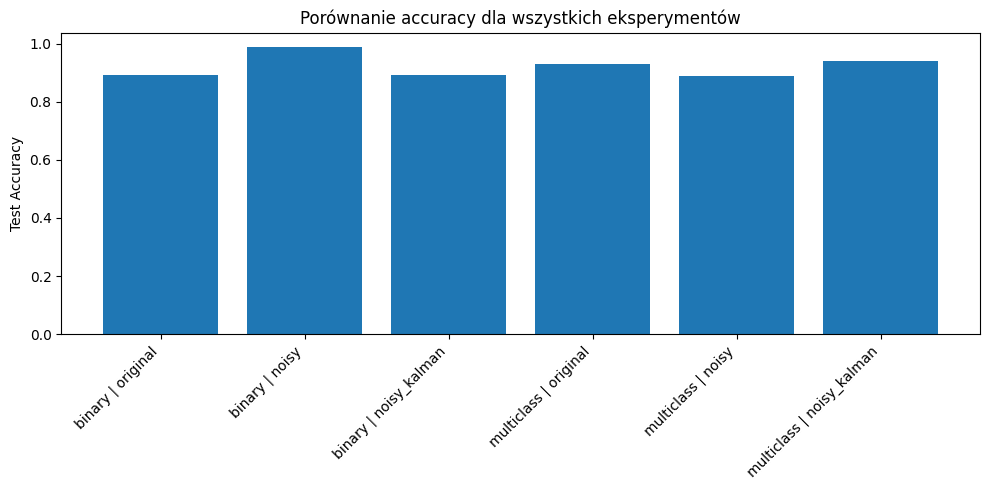

In [16]:
plt.figure(figsize=(10, 5))

labels = results_df["dataset_type"] + " | " + results_df["variant"]
values = results_df["test_acc"]

plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy")
plt.title("Porównanie accuracy dla wszystkich eksperymentów")
plt.tight_layout()
plt.show()

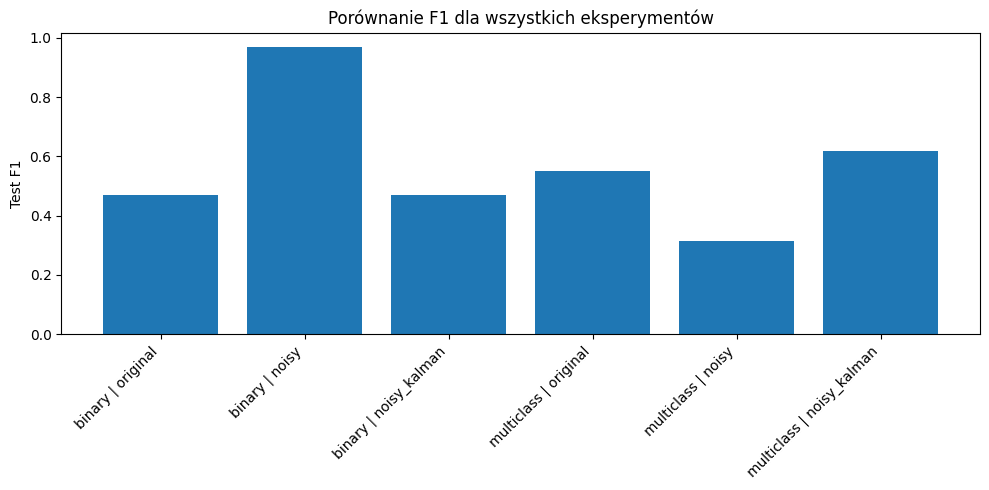

In [17]:
plt.figure(figsize=(10, 5))

labels = results_df["dataset_type"] + " | " + results_df["variant"]
values = results_df["test_f1"]

plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test F1")
plt.title("Porównanie F1 dla wszystkich eksperymentów")
plt.tight_layout()
plt.show()